<a href="https://colab.research.google.com/github/Fatimalbasha/KAUST-Labs2026/blob/main/Stage2/Day_1/Day1_Exercise_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image.png](https://i.imgur.com/a3uAqnb.png)

## **Goal:** Build a classification model to predict the rarity of pokemon cards (normal vs legendary).

# 1️⃣ Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Load the Data

In [ ]:
# Download dataset
path = kagglehub.dataset_download("rounakbanik/pokemon")
print("Path:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path: /kaggle/input/pokemon


In [ ]:
# TODO: Load the CSV file into df_pokemon


pokemon_path = os.path.join(path, 'pokemon.csv')
df_pokemon = pd.read_csv(pokemon_path)

print(f"Shape: {df_pokemon.shape}")
df_pokemon.head()

Shape: (801, 41)


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


# 3️⃣ EDA

In [ ]:
# TODO: Check the data info and missing values
# YOUR CODE HERE

df_pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

 **Check for Missing Values**

In [ ]:
missing_percentage = (df_pokemon.isnull().sum() / len(df_pokemon)) * 100

missing_data = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing_Percentage': missing_percentage.values
})

missing_data = missing_data[missing_data['Missing_Percentage'] > 0].sort_values('Missing_Percentage', ascending=False)


print("Missing Data Analysis:")
missing_data



Missing Data Analysis:


,Column,Missing_Percentage
37,type2,47.940075
31,percentage_male,12.234707
27,height_m,2.496879
38,weight_kg,2.496879


In [ ]:
# TODO: Check for target imbalance
# Hint: the target column is 'is_legendary'
# YOUR CODE HERE

print(f"Legendary: {df_pokemon['is_legendary'].sum()}")
print(f"Normal(non-legendary): {(df_pokemon['is_legendary'] == 0).sum()}")


Legendary: 70
Normal(non-legendary): 731


> **Finding:** Class imbalance - very few Legendary Pokemon. Need stratified split and F1 metric.

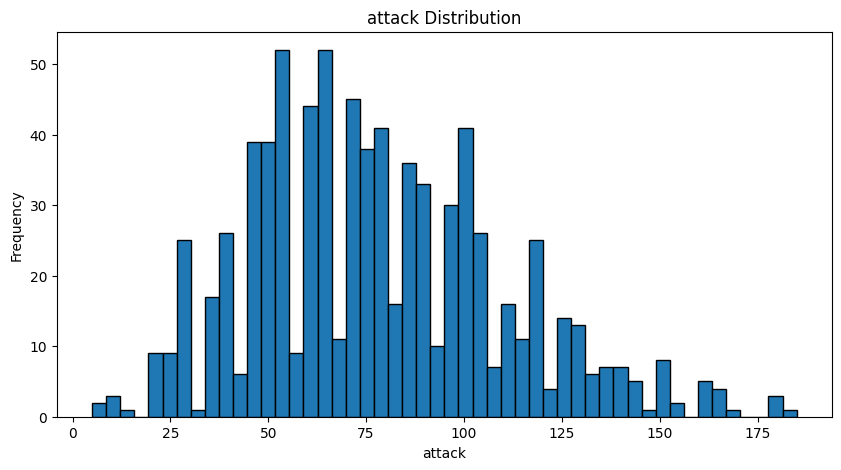

In [ ]:
# TODO: Plot distribution of the stats (e.g., 'attack')
# YOUR CODE HERE

# Attack distribution
plt.figure(figsize=(10, 5))
plt.hist(df_pokemon['attack'].dropna(), bins=50, edgecolor='black')
plt.title('attack Distribution')
plt.xlabel('attack')
plt.ylabel('Frequency')
plt.show()



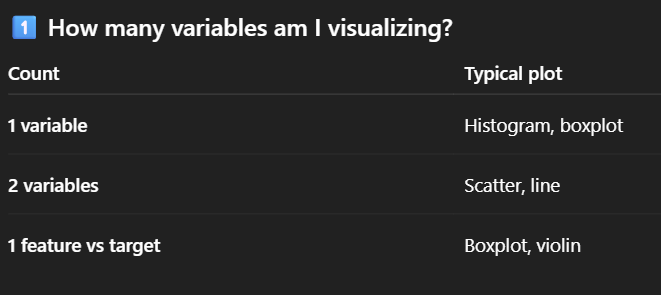

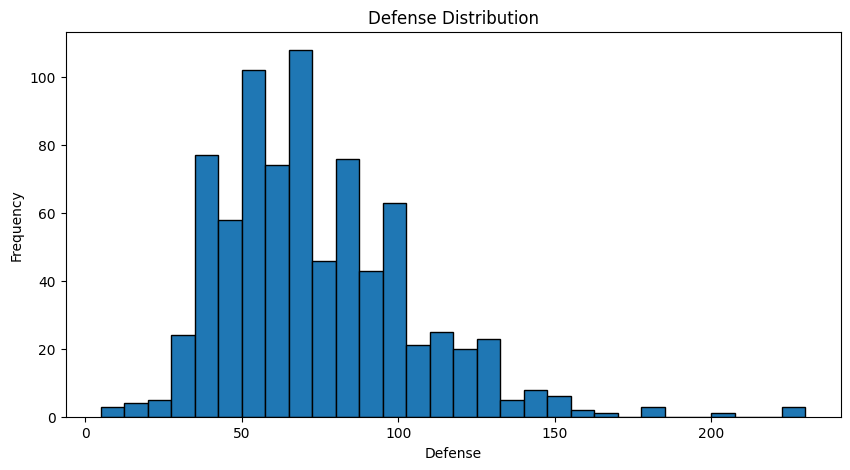

In [ ]:
# Defense distribution
plt.figure(figsize=(10, 5))
plt.hist(df_pokemon['defense'].dropna(), bins=30, edgecolor='black')
plt.title('Defense Distribution')
plt.xlabel('Defense')
plt.ylabel('Frequency')
plt.show()

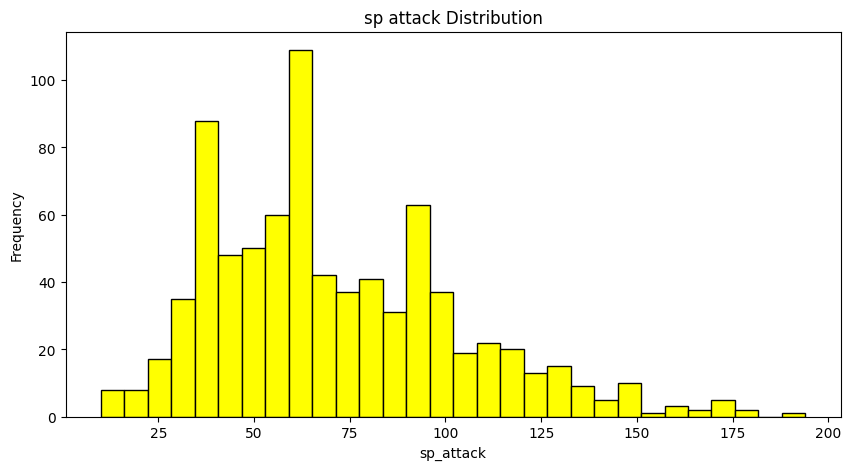

In [ ]:
# sp_attack distribution
plt.figure(figsize=(10, 5))
plt.hist(df_pokemon['sp_attack'].dropna(), bins=30, edgecolor='black', color = 'yellow')
plt.title('sp attack Distribution')
plt.xlabel('sp_attack')
plt.ylabel('Frequency')
plt.show()

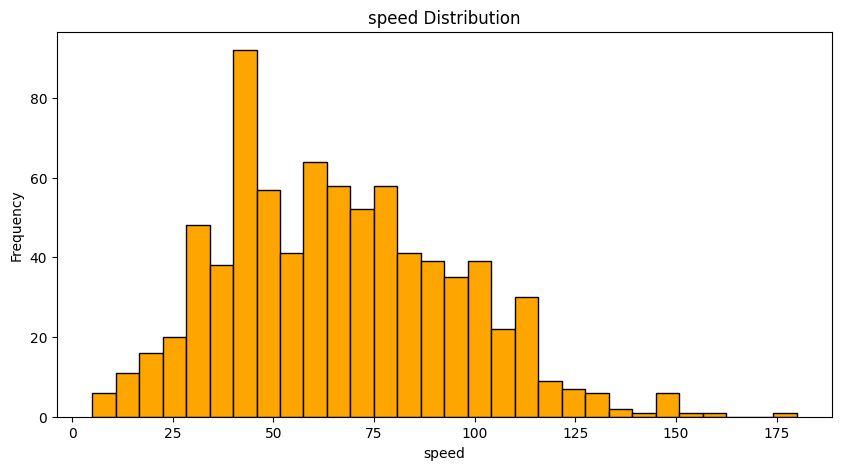

In [ ]:
# speed distribution
plt.figure(figsize=(10, 5))
plt.hist(df_pokemon['speed'].dropna(), bins=30, edgecolor='black', color = "orange")
plt.title('speed Distribution')
plt.xlabel('speed')
plt.ylabel('Frequency')
plt.show()

# 4️⃣ Data Cleaning

In [ ]:
# Define stat columns
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# TODO: Drop rows with missing stat values
df_clean = df_pokemon.dropna(subset=stat_cols).copy()

print(f"Shape after cleaning: {df_clean.shape}")

Shape after cleaning: (801, 41)


In [ ]:
print("Missing values remaining:", df_clean.isnull().sum().sum())
# First .sum() → per column
# Second .sum() → total missing cells

Missing values remaining: 522


In [ ]:
# TODO: Fill missing type2
df_clean['type2'] = df_clean['type2'].fillna('none')


# 5️⃣ Encode Categorical Variables

In [ ]:
# TODO: Encode type1 and type2 using LabelEncoder
le = LabelEncoder()
df_clean['type1'] = le.fit_transform(df_clean['type1'])
df_clean['type2'] = le.fit_transform(df_clean['type2'].astype(str))

df_clean.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,9,14,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,9,14,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,9,14,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,6,12,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,6,12,19.0,1,0


# 6️⃣ Feature Engineering

In [ ]:
# TODO: Create total_stats feature (sum of all stat columns)
df_clean['total_stats'] = df_clean[stat_cols].sum(axis=1)
# axis=1 means “sum across columns for each row” → one total per Pokémon
# default --> axis=0 (Sums each column separately)

# TODO: Create attack_defense_ratio feature
df_clean['attack_defense_ratio'] = df_clean['attack'] / (df_clean['defense'] + 1 )
# +1 is a simple guard to avoid divide-by-zero.
# (In Pokémon data, defense probably isn’t 0, but this is a common safe habit.)

df_clean[['total_stats','attack_defense_ratio']].head()

,total_stats,attack_defense_ratio
0,318,0.980000
1,405,0.968750
2,625,0.806452
3,309,1.181818
4,405,1.084746


# 7️⃣ Prepare Data

In [ ]:
# Define features and target
feature_cols = stat_cols + ['total_stats', 'attack_defense_ratio', 'type1', 'type2']

X = df_clean[feature_cols]
y = df_clean['is_legendary']

# TODO: Split data with stratification (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Legendary in train: {y_train.sum()}, in test: {y_test.sum()}")

Train: (640, 10), Test: (161, 10)
Legendary in train: 56, in test: 14


In [ ]:
from pandas.core.tools.datetimes import Scalar
# TODO: Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8️⃣ Train Model
### Challenge : Try to get > 99% F1 score

In [ ]:
# TODO: Train RandomForestClassifier with class_weight='balanced'
model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced' )

# YOUR CODE HERE - fit the model
model.fit(X_train_scaled, y_train)
print("Model trained!")

Model trained!


**What does `class_weight='balanced'` do?**

When you have **class imbalance** (e.g., 700 Normal Pokemon, 50 Legendary), models tend to:
- Predict the majority class most of the time
- Ignore the minority class (it's "cheaper" to be wrong on rare cases)

`class_weight='balanced'` fixes this by:
1. Calculating weight for each class: `weight = n_samples / (n_classes * n_samples_in_class)`
2. Giving **higher penalty** to misclassifying the minority class
3. Example: If Normal:Legendary ratio is 10:1, Legendary errors cost 10x more


**Result:** Model pays equal attention to both classes, improving recall on minority class.

# 9️⃣ Evaluate Model

In [ ]:
# TODO: Make predictions and print accuracy
y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Legendary']))

Accuracy: 0.9814
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       147
   Legendary       1.00      0.79      0.88        14

    accuracy                           0.98       161
   macro avg       0.99      0.89      0.93       161
weighted avg       0.98      0.98      0.98       161



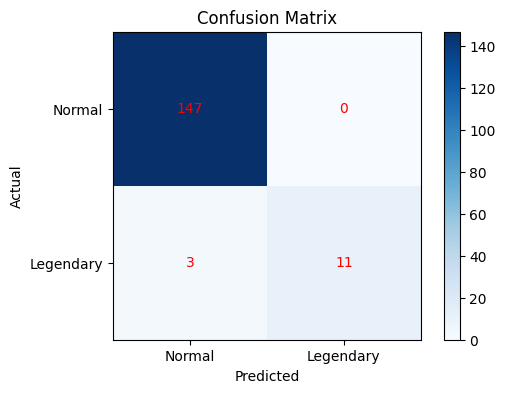

In [ ]:
# TODO: Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# what does labels = model.classes_ mean?
# The actual class labels the model learned during training
# Stored in a fixed order
# For your case, it will be something like:
# model.classes_
#  array([0, 1])
# 0 → Normal
# 1 → Legendary
# Build the confusion matrix using this exact class order.


plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Normal', 'Legendary'])
plt.yticks([0, 1], ['Normal', 'Legendary'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

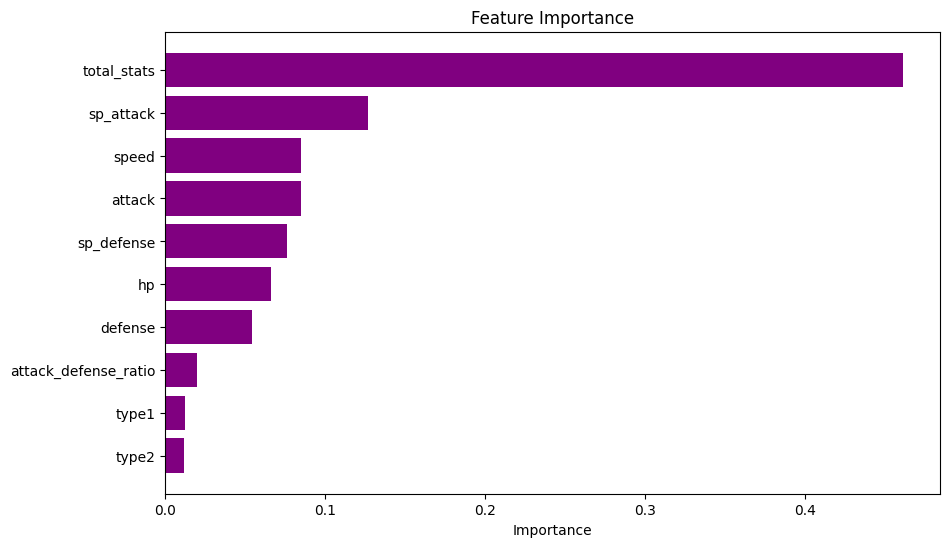

In [ ]:
# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='purple')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()